In [ ]:
import numpy as np 
import pandas as pd 
import tensorflow as tf
from keras.models import Sequential
from keras.models import load_model
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Dense, Dropout
import math
import datasets

In [2]:
from sympy import sympify

def solver(formula, values):
    modified = ''
    form = formula.split(' ')

    for i in range(len(form)):
        if form[i] in values:
            modified += str(values[form[i]])
        else:
            if form[i][0] != 'n':
                modified += form[i]
            else:
                modified += '1'  # To deal with spurious variables
    
    try:
        answer = sympify(modified).evalf()  # Safe evaluation
    except ZeroDivisionError:
        answer = 0
    except Exception:
        answer = None  # Handle invalid expressions safely

    return answer

In [3]:
# Convert numbers written as words to numbers 

from word2number import w2n  

def convert_number_words(text):  
    words = text.split()  # Tokenize by spaces  
    converted_words = []  

    for word in words:  
        try:  
            converted_words.append(str(w2n.word_to_num(word)))  # Convert if it's a number  
        except ValueError:  
            converted_words.append(word)  # Keep original if it's not a number  

    return " ".join(converted_words)  

In [4]:
# A cleaning fucntion which removes question marks, fullstops and commas

import re

def cleaner(s):
    return re.sub(r"[?,.]","",s)

In [5]:
# Space creator

def space_maker(s):
    n=s[0]
    i=1
    p=0
    while s[i]!='=':
        if s[i-1].isnumeric() and s[i].isnumeric():
            n+=s[i]
        else:
            n+=" "+s[i]
        i+=1
        if i==len(s):
            break
        if s[i]=='=':
            p=1
    if p==0:
        return(None)
    return(n)

In [6]:
import ast

def is_math_expression(s):
    try:
        tree = ast.parse(s, mode='eval')  # Parse the expression
        for node in ast.walk(tree):  # Walk through AST nodes
            if not isinstance(node, (ast.Expression, ast.BinOp, ast.UnaryOp, 
                                     ast.Num, ast.Name, ast.Load, ast.operator)):
                return False
        return True
    except (SyntaxError, ValueError):
        return False


In [7]:
def form2gen(st):
    st = cleaner(st)
    st = convert_number_words(st)
    f=''
    c=0
    values={}
    tok=st.split(" ")
    for i in range(len(tok)):
        if tok[i].isnumeric():
            if c<10:
                f+='n_0'+str(c)
                values['n_0'+str(c)] = tok[i]
            else:
                f+='n_'+str(c)
                values['n_'+str(c)] = tok[i]
            c+=1
            
        else:
            f+=tok[i]
        f+=" "
    return(f,values)

In [8]:
# Takes questions as input and replaces the numbers with variables 

def form2gen2(st):
    st = cleaner(st)
    st = convert_number_words(st)
    f=''
    c=0
    values={}
    rev={}
    tok=st.split(" ")
    for i in range(len(tok)):
        if tok[i].isnumeric():
            if c<10:
                var='N_0'+str(c)
                f+=var
                values['N_0'+str(c)] = tok[i]
            else:
                var='N_'+str(c)
                f+=var
                values['N_'+str(c)] = tok[i]
            c+=1
            if tok[i] in rev.keys():
                return(0)
            rev[tok[i]] = var
        else:
            f+=tok[i]
        f+=" "
    return(f,values,rev)

In [ ]:
# Training dataset

df=pd.read_csv("/home/ishan/Downloads/mawps_train.csv")
total_problem_phrases1 = list(df['Question'])
total_formula_phrases1 = list(df['Equation'])
train_answers = list(df['Answer'])
df.head()

In [ ]:
# Test dataset 1

df2=pd.read_csv("/home/ishan/Downloads/sigmadolphin.csv")
test_total_problem_phrases = list(df2['Problem'])
test_answers = list(df2['Answer'])
#print(test_total_problem_phrases[10])
#print(test_answers[10])

df2.head()

In [ ]:
# Train dataset 2

df3=pd.read_csv("/home/ishan/Downloads/ASDiv.csv")
test_body = list(df3['Body'])
test_question = list(df3['Question']) 
test_total_problem_phrases = [test_body[x]+test_question[x] for x in range(len(df3))]
test_answers1 = list(df3['Answer'])
test_answers = [x.split()[0] for x in test_answers1]
#test_total_problem_phrases = list(df['Problem'])
#test_answers = list(df['Answer'])

df3.head()

In [ ]:
# Cleaning of Train dataset 2

df4=pd.read_csv("/home/ishan/Downloads/ASDiv.csv")
test_body = list(df4['Body'])
test_question = list(df4['Question']) 
total_problem_phrases2 = [test_body[x]+". "+test_question[x] for x in range(len(df4))]
total_formula_phrases2 = list(df4['Formula'])
test_formulas=[]
#test_total_problem_phrases = list(df['Problem'])
#test_answers = list(df['Answer'])
def convert(st,rev):
    form = ''
    l=st.split()
    for i in range(len(l)):
        if l[i] in rev.keys():
            form+=rev[l[i]]
        else:
            form+=l[i]
    return(form)

buff_probs=[]

for j in range(len(df4)):
    op=form2gen2(total_problem_phrases2[j])
    st=space_maker(total_formula_phrases2[j])
    if op != 0 and st!=None:
        expr = convert(st,op[2])
        if is_math_expression(expr):
            test_formulas+= [expr]
            buff_probs += [op[0]]
total_problem_phrases2 = buff_probs

len(test_formulas)

In [ ]:
# Combining dataset
total_problem_phrases = total_problem_phrases1+total_problem_phrases2
total_formula_phrases = total_formula_phrases1+test_formulas
print(len(total_formula_phrases))
print(len(total_problem_phrases))
print(len(total_problem_phrases1))
print(len(total_problem_phrases2))


In [14]:
# Checks if two formulas are same 

def checker(formula,output):
    formula_list = formula.split(" ")
    modified = ""
    for i in range(0,len(formula_list)):
        buff = ""
        for j in range(len(formula_list[i])):
            if formula_list[i][j]=='N':
                buff+='n'
            else:
                buff+=formula_list[i][j]
        modified+=buff+" "
    output+=" "
    return(modified==output)

In [15]:
import random

sample_size = 3336
print(len(total_problem_phrases))
serials = random.sample(range(len(total_problem_phrases)), sample_size)
problem_phrases = [total_problem_phrases[x] for x in serials]
formula_phrases = [total_formula_phrases[x] for x in serials]
#problem_phrases = total_problem_phrases
formula_phrases = [f'<start> {phrase} <end>' for phrase in formula_phrases]

3436


In [ ]:
# Main model which includes Encoder Decoder with attention

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Attention
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def tokenize_and_pad(sequences, max_len):
    tokenizer = Tokenizer(filters='')
    tokenizer.fit_on_texts(sequences)
    sequences = tokenizer.texts_to_sequences(sequences)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded_sequences, tokenizer

max_len_eng = max(len(seq.split()) for seq in problem_phrases)
max_len_fr = max(len(seq.split()) for seq in formula_phrases)

input_sequences, input_tokenizer = tokenize_and_pad(problem_phrases, max_len_eng)
output_sequences, output_tokenizer = tokenize_and_pad(formula_phrases, max_len_fr)

num_encoder_tokens = len(input_tokenizer.word_index) + 1
num_decoder_tokens = len(output_tokenizer.word_index) + 1

encoder_inputs = Input(shape=(None,))
encoder_embedding = Embedding(num_encoder_tokens, 256)(encoder_inputs)
encoder_lstm = LSTM(256, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(None,))
decoder_embedding = Embedding(num_decoder_tokens, 256)(decoder_inputs)
decoder_lstm = LSTM(256, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

attention = Attention()([decoder_outputs, encoder_outputs])
decoder_combined_context = tf.keras.layers.Concatenate(axis=-1)([decoder_outputs, attention])
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_combined_context)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

def one_hot_encode(sequences, num_classes):
    return np.array([tf.keras.utils.to_categorical(seq, num_classes=num_classes) for seq in sequences])

decoder_target_data = one_hot_encode(output_sequences[:, 1:], num_decoder_tokens)

history = model.fit(
    [input_sequences, output_sequences[:, :-1]], 
    decoder_target_data,
    batch_size=64,
    epochs=22,                                    # Adjust the number of epochs to achieve better results 
    validation_split=0.1
)

encoder_model = Model(encoder_inputs, [encoder_outputs] + encoder_states)

decoder_state_input_h = Input(shape=(256,))
decoder_state_input_c = Input(shape=(256,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_hidden_state_input = Input(shape=(max_len_eng, 256))
decoder_outputs, state_h, state_c = decoder_lstm(decoder_embedding, initial_state=decoder_states_inputs)

attention_inf = Attention()([decoder_outputs, decoder_hidden_state_input])
decoder_combined_context_inf = tf.keras.layers.Concatenate(axis=-1)([decoder_outputs, attention_inf])
decoder_outputs = decoder_dense(decoder_combined_context_inf)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs + [decoder_hidden_state_input],
    [decoder_outputs] + [state_h, state_c]
)

def decode_sequence(input_seq):
    encoder_outputs, state_h, state_c = encoder_model.predict(input_seq)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = output_tokenizer.word_index['<start>']
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_seq, state_h, state_c, encoder_outputs]
        )
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = output_tokenizer.index_word[sampled_token_index]
        decoded_sentence += ' ' + sampled_word
        if sampled_word == '<end>' or len(decoded_sentence) > max_len_fr:
            stop_condition = True
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        state_h, state_c = h, c
    return decoded_sentence.replace('<start>', '').replace('<end>', '').strip()

In [25]:
loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
# Test over the split data

import numpy as np
import random
corrects=[]
countA=0
answers=[]
for r in range(len(total_problem_phrases)):
    if r not in serials:
        #r = random.randint(0,100)
        # Select a sample problem phrase
        cleaned = form2gen(total_problem_phrases[r])
        sample_problem = cleaned[0]  # Change index to test different inputs
        vals = cleaned[1]
        sample_output = total_formula_phrases[r]
        
        # Tokenize and pad the input sequence
        input_seq = input_tokenizer.texts_to_sequences([sample_problem])
        input_seq = pad_sequences(input_seq, maxlen=max_len_eng, padding='post')

        # Decode the sequence using the trained model
        output_formula = decode_sequence(input_seq)
        if checker(sample_output,output_formula):
            countA+=1
            corrects+=[[sample_output,output_formula]]
        answers+=[[sample_problem,output_formula]]
# Print the predicted formula
#print(f"Predicted Formula: {output_formula}")

In [ ]:
# Test over the different data
# For later usage

import numpy as np
import random
corrects=[]
countB=0
answers=[]
for r in range(100): # Choose your test dataset
    #r = random.randint(0,100)
    # Select a sample problem phrase
    cleaned = form2gen(test_total_problem_phrases[r])
    sample_problem = cleaner(cleaned[0])  # Change index to test different inputs
    vals = cleaned[1]
    sample_output = test_answers[r]
    
    # Tokenize and pad the input sequence
    input_seq = input_tokenizer.texts_to_sequences([sample_problem])
    input_seq = pad_sequences(input_seq, maxlen=max_len_eng, padding='post')

    # Decode the sequence using the trained model
    output_formula = decode_sequence(input_seq)
    #if checker(sample_output,output_formula):
    if solver(output_formula,vals)==sample_output:
        countB+=1
        corrects+=[[sample_output,output_formula]]
    answers+=[[sample_problem,output_formula]]
# Print the predicted formula
#print(f"Predicted Formula: {output_formula}")

In [ ]:
#BLEU score

# Test over the split data

import numpy as np
from nltk.translate.bleu_score import sentence_bleu , SmoothingFunction
answers=[]
score=0
for r in range(len(total_problem_phrases)):
    if r not in serials:
        #r = random.randint(0,100)
        # Select a sample problem phrase
        cleaned = form2gen(total_problem_phrases[r])
        sample_problem = cleaned[0]  # Change index to test different inputs
        vals = cleaned[1]
        sample_output = total_formula_phrases[r]
        
        # Tokenize and pad the input sequence
        input_seq = input_tokenizer.texts_to_sequences([sample_problem])
        input_seq = pad_sequences(input_seq, maxlen=max_len_eng, padding='post')

        # Decode the sequence using the trained model
        output_formula = decode_sequence(input_seq)
        
        answers+=[[sample_problem,output_formula]]

        ref_toks = sample_output.split()
        cand_toks = output_formula.split()
        smoothie = SmoothingFunction().method4

        score+=sentence_bleu([ref_toks],cand_toks,smoothing_function = smoothie)

# Print the predicted formula
#print(f"Predicted Formula: {output_formula}")

In [ ]:
# Final Score
print("Training",countA,"/",len(answers))
#print("Test",countB,"/",len(test_answers))
#print("BLEU:",score/100)

In [ ]:
#For the records

marks = [0,1,8.66,9,9.33,9,9,8.66,10.5,8,10]
epochs = [1,3,5,7,10,12,15,17,20,22,25]

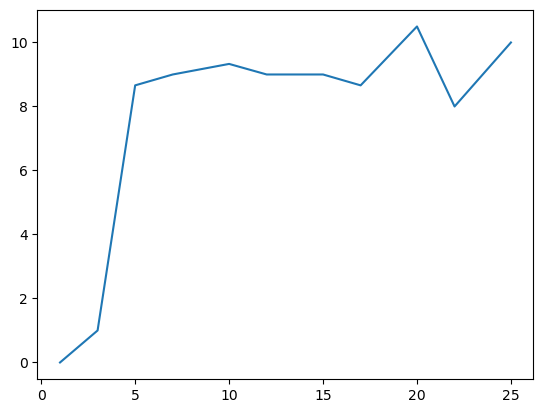

In [88]:
import matplotlib.pyplot as plt
plt.plot(epochs, marks)
plt.show()

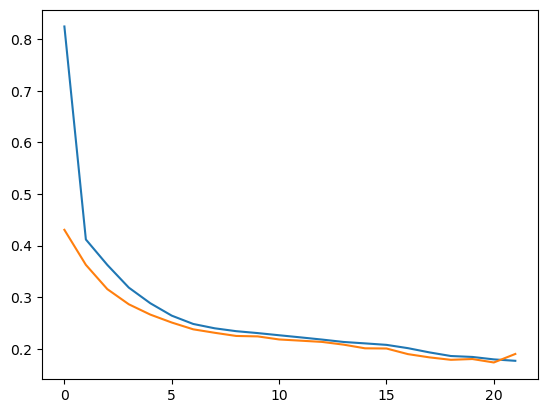

In [94]:
import matplotlib.pyplot as plt
plt.plot(range(len(loss)), loss)
plt.plot(range(len(val_loss)), val_loss)
plt.show()